In [1]:
# Set the root path to your project directory
import pathlib

root = pathlib.Path(r"c:\Users\26293\Desktop\WORK\emhass_git\emhass")
print(root)
print(list((root / "data").glob("*")))  # List files in the data folder

c:\Users\26293\Desktop\WORK\emhass_git\emhass
[WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/actionLogs.txt'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/adjust_pv_regressor.pkl'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/cached-open-meteo-forecast.json'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_load_cost_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_load_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_prod_price_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_weather_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/debug-adjust-pv-forecast-data-prep-input-data.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/debug-adjust-pv-forecast-data-prep-output-data.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/debug-ad

In [2]:
import pickle

# Load the pickle file
with open(root / "data" / "long_train_data.pkl", "rb") as inp:
    data = pickle.load(inp)

# Check the type and length of the loaded object
print(type(data))
print(len(data))

df_final, days_list, var_list, ha_config = data

# Show the DataFrame
print(df_final.head())
print("days_list:", days_list)
print("var_list:", var_list)
print("ha_config:", ha_config)

<class 'tuple'>
4
                           sensor.power_load_no_var_loads  \
2024-02-28 21:00:00+00:00                             0.0   
2024-02-28 21:30:00+00:00                             0.0   
2024-02-28 22:00:00+00:00                             NaN   
2024-02-28 22:30:00+00:00                             NaN   
2024-02-28 23:00:00+00:00                             NaN   

                           sensor.power_photovoltaics  sensor.p_pv_forecast  
2024-02-28 21:00:00+00:00                         0.0                  -1.5  
2024-02-28 21:30:00+00:00                         0.0                  -1.5  
2024-02-28 22:00:00+00:00                         NaN                   NaN  
2024-02-28 22:30:00+00:00                         NaN                   NaN  
2024-02-28 23:00:00+00:00                         NaN                   NaN  
days_list: DatetimeIndex(['2024-02-28 21:00:00+00:00', '2024-02-29 21:00:00+00:00',
               '2024-03-01 21:00:00+00:00', '2024-03-02 21:00:0

C:\Users\26293\AppData\Local\Temp\ipykernel_25132\2426249113.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(inp)


In [3]:
import pickle
import pathlib
import pandas as pd
from emhass.machine_learning_forecaster import MLForecaster
from emhass.forecast import Forecast
from emhass import utils

# Setup paths and logger
root = pathlib.Path(r"c:\Users\26293\Desktop\WORK\emhass_git\emhass")
emhass_conf = {
    "data_path": root / "data/",
    "root_path": root / "src/emhass/",
    "defaults_path": root / "src/emhass/data/config_defaults.json",
    "associations_path": root / "src/emhass/data/associations.csv",
}
logger, ch = utils.get_logger("notebook", emhass_conf, save_to_file=False)

# Load test data
with open(emhass_conf["data_path"] / "long_train_data.pkl", "rb") as inp:
    df_final, days_list, var_list, ha_config = pickle.load(inp)


c:\Users\26293\Desktop\WORK\emhass_git\emhass\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_final.tail()

,sensor.power_load_no_var_loads,sensor.power_photovoltaics,sensor.p_pv_forecast
2025-02-27 20:30:00+00:00,3478.084000,NaN,NaN
2025-02-27 21:00:00+00:00,3409.921111,0.0,-0.55
2025-02-27 21:30:00+00:00,3344.159392,NaN,NaN
2025-02-27 22:00:00+00:00,1563.476536,NaN,NaN
2025-02-27 22:30:00+00:00,1532.535000,NaN,NaN


In [5]:
df_final.to_csv("long_train_data.csv", index=True, index_label="datetime")

In [6]:
model_type = "long_train_data"
var_model = "sensor.power_load_no_var_loads"
sklearn_model = "KNeighborsRegressor"
num_lags = 48

mlf = MLForecaster(df_final, model_type, var_model, sklearn_model, num_lags, emhass_conf, logger)
# mlf.fit()
# Display basic configuration parameters
print("==== MLForecaster Configuration ====")
print(f"Model type: {mlf.model_type}")
print(f"Target variable: {mlf.var_model}")
print(f"sklearn model: {mlf.sklearn_model}")
print(f"Number of lags: {mlf.num_lags}")
print("\n==== Data Info ====")
print(f"Data frequency: {mlf.data.index.freq}")
print(f"Data range: {mlf.data.index.min()} to {mlf.data.index.max()}")
print(f"Data points: {len(mlf.data)}")
# forecast = mlf.predict()
# forecast.tail()

==== MLForecaster Configuration ====
Model type: long_train_data
Target variable: sensor.power_load_no_var_loads
sklearn model: KNeighborsRegressor
Number of lags: 48

==== Data Info ====
Data frequency: <30 * Minutes>
Data range: 2024-02-28 21:00:00+00:00 to 2025-02-27 22:30:00+00:00
Data points: 17524


In [7]:
df_pred, df_pred_backtest = mlf.fit()
print(df_pred.tail())

2025-07-22 16:50:01,940 - notebook - INFO - Performing a forecast model fit for long_train_data
2025-07-22 16:50:01,954 - notebook - INFO - Training a KNeighborsRegressor model
2025-07-22 16:50:03,823 - notebook - INFO - Elapsed time for model fit: 1.8670363426208496
2025-07-22 16:50:03,879 - notebook - INFO - Prediction R2 score of fitted model on test data: 0.6744325622623472


                           train         test         pred
2025-02-27 20:30:00+00:00    NaN  3478.084000  2785.092309
2025-02-27 21:00:00+00:00    NaN  3409.921111  2403.638126
2025-02-27 21:30:00+00:00    NaN  3344.159392  2291.353380
2025-02-27 22:00:00+00:00    NaN  1563.476536   686.501510
2025-02-27 22:30:00+00:00    NaN  1532.535000  1444.213008


                                  test        pred
2025-02-25 23:00:00+00:00  3482.792056  634.792300
2025-02-25 23:30:00+00:00  1557.221215  447.119718
2025-02-26 00:00:00+00:00   914.423966  452.474830
2025-02-26 00:30:00+00:00   266.457207  500.020360
2025-02-26 01:00:00+00:00   232.014222  485.070890


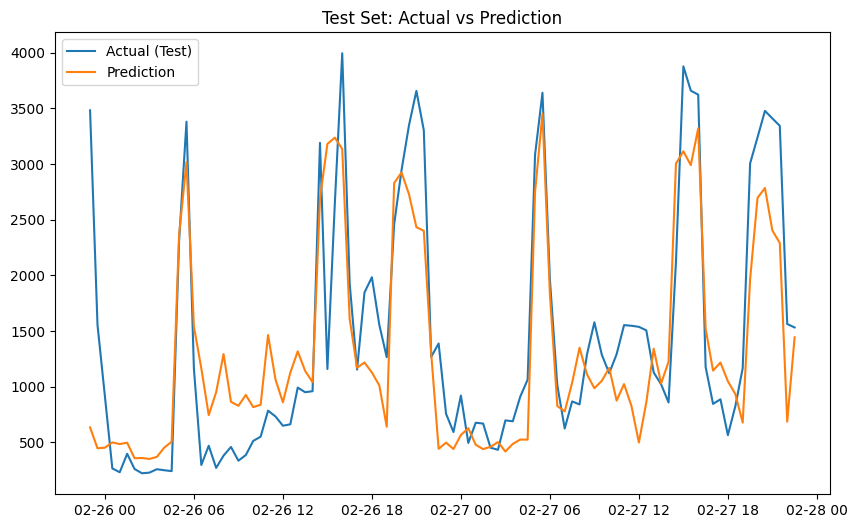

In [12]:
# Only keep rows where both test and pred are not NaN
test_comparison = df_pred[["test", "pred"]].dropna()
print(test_comparison.head())

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(test_comparison.index, test_comparison["test"], label="Actual (Test)")
plt.plot(test_comparison.index, test_comparison["pred"], label="Prediction")
plt.legend()
plt.title("Test Set: Actual vs Prediction")
plt.show()

In [13]:
import plotly.graph_objs as go
from plotly.offline import iplot

# Create interactive plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=test_comparison.index, y=test_comparison["test"], mode='lines', name='Actual (Test)'))
fig.add_trace(go.Scatter(x=test_comparison.index, y=test_comparison["pred"], mode='lines', name='Prediction'))

fig.update_layout(
    title="Test Set: Actual vs Prediction (Interactive)",
    xaxis_title="Time",
    yaxis_title="Value",
    legend=dict(x=0, y=1),
    hovermode="x unified" 
)

iplot(fig)

In [15]:
# Calculate multiple evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# R² score
r2 = r2_score(test_comparison["test"], test_comparison["pred"])
# Mean Absolute Error
mae = mean_absolute_error(test_comparison["test"], test_comparison["pred"])
# Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(test_comparison["test"], test_comparison["pred"]))
# Mean Absolute Percentage Error - with handling for zeros
def calculate_mape(y_true, y_pred):
    """Calculate MAPE with handling for zero values."""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape = calculate_mape(test_comparison["test"].values, test_comparison["pred"].values)

# Display metrics
print("\nModel Performance Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (sensitive to large errors): {rmse:.4f}")
print(f"MAPE (relative error): {mape:.2f}%")



Model Performance Metrics:
R² Score: 0.6744
MAE (Mean Absolute Error): 461.5739
RMSE (sensitive to large errors): 621.9357
MAPE (relative error): 46.42%


In [20]:
# Calculate residuals
test_comparison["residuals"] = test_comparison["test"] - test_comparison["pred"]

# Extract time of day information
test_comparison["hour"] = test_comparison.index.hour

test_comparison.head()

,test,pred,hour,residuals
2025-02-25 23:00:00+00:00,3482.792056,634.792300,23,2847.999755
2025-02-25 23:30:00+00:00,1557.221215,447.119718,23,1110.101497
2025-02-26 00:00:00+00:00,914.423966,452.474830,0,461.949136
2025-02-26 00:30:00+00:00,266.457207,500.020360,0,-233.563153
2025-02-26 01:00:00+00:00,232.014222,485.070890,1,-253.056668


In [10]:
df_pred, df_pred_backtest = mlf.fit(perform_backtest=True)
print(df_pred_backtest.tail())

2025-07-17 09:43:18,224 - notebook - INFO - Performing a forecast model fit for long_train_data
2025-07-17 09:43:18,232 - notebook - INFO - Training a KNeighborsRegressor model
2025-07-17 09:43:18,479 - notebook - INFO - Elapsed time for model fit: 0.24602437019348145
2025-07-17 09:43:18,539 - notebook - INFO - Prediction R2 score of fitted model on test data: 0.6744325622623472
2025-07-17 09:43:18,546 - notebook - INFO - Performing simple backtesting of fitted model
100%|██████████| 363/363 [00:05<00:00, 62.30it/s] 
2025-07-17 09:43:24,735 - notebook - INFO - Elapsed backtesting time: 6.188895225524902
2025-07-17 09:43:24,735 - notebook - INFO - Backtest R2 score:    neg_r2_score
0      0.525065


                                 train  pred
2025-02-27 20:30:00+00:00  3478.084000   NaN
2025-02-27 21:00:00+00:00  3409.921111   NaN
2025-02-27 21:30:00+00:00  3344.159392   NaN
2025-02-27 22:00:00+00:00  1563.476536   NaN
2025-02-27 22:30:00+00:00  1532.535000   NaN


In [11]:
test_backtest_comparison = df_pred_backtest[["train", "pred"]].dropna()
test_backtest_comparison.tail()

,train,pred
2025-02-25 20:30:00+00:00,3334.416333,2257.786810
2025-02-25 21:00:00+00:00,2808.148122,2823.102614
2025-02-25 21:30:00+00:00,3894.229116,2818.362390
2025-02-25 22:00:00+00:00,1286.109162,746.700659
2025-02-25 22:30:00+00:00,2004.290331,787.769811


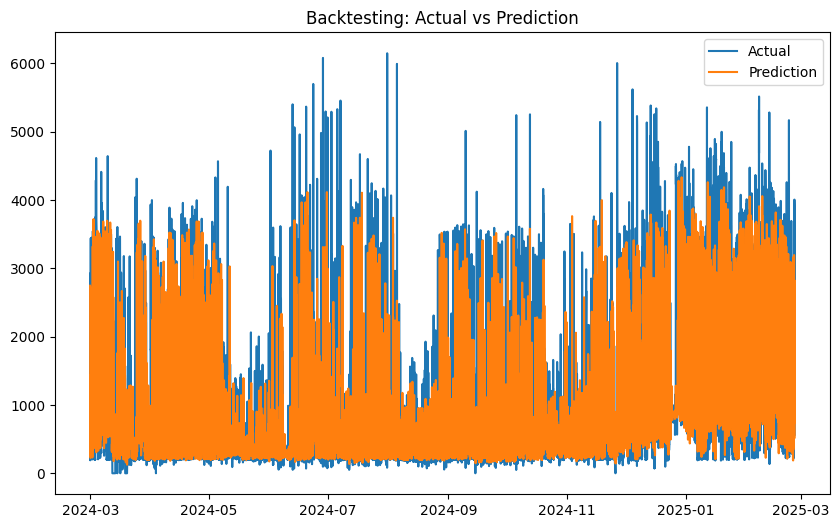

In [12]:
# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(test_backtest_comparison.index, test_backtest_comparison["train"], label="Actual")
plt.plot(test_backtest_comparison.index, test_backtest_comparison["pred"], label="Prediction")
plt.legend()
plt.title("Backtesting: Actual vs Prediction")
plt.show()

In [13]:
import plotly.graph_objs as go
from plotly.offline import iplot

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=test_backtest_comparison.index.strftime("%Y-%m-%d %H:%M:%S"),
    y=test_backtest_comparison["train"],
    mode='lines',
    name='Actual'
))
fig.add_trace(go.Scatter(
    x=test_backtest_comparison.index.strftime("%Y-%m-%d %H:%M:%S"),
    y=test_backtest_comparison["pred"],
    mode='lines',
    name='Prediction'
))

fig.update_layout(
    title="Backtesting: Actual vs Prediction (Interactive)",
    xaxis_title="Time",
    yaxis_title="Value (W)",
    legend=dict(x=0, y=1),
    hovermode="x unified",
    xaxis=dict(
        tickformat='%Y-%m-%d %H:%M:%S',
        rangeslider=dict(visible=True),  # Add slider for time selection
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1d", step="day", stepmode="backward"),
                dict(count=7, label="1w", step="day", stepmode="backward"),
                dict(step="all")
            ])
        )
    )
)

iplot(fig)

In [14]:
# Forecast next day
forecast = mlf.predict(data_last_window=df_final)
forecast.head()

2025-02-27 23:00:00+00:00     501.047431
2025-02-27 23:30:00+00:00     617.438523
2025-02-28 00:00:00+00:00     694.734592
2025-02-28 00:30:00+00:00    1068.957456
2025-02-28 01:00:00+00:00     646.215270
Freq: 30min, Name: pred, dtype: float64

In [15]:
# # First fit with larger tuning window
# df_pred, _ = mlf.fit(tuning_days="30days")  

# Then tune using that window
df_pred_opt = mlf.tune()
df_pred_opt.head()

2025-07-17 09:43:25,457 - notebook - INFO - Bayesian hyperparameter optimization with backtesting
Best trial: 1. Best value: -0.240458: 100%|██████████| 10/10 [00:02<00:00,  4.79it/s]
2025-07-17 09:43:27,876 - notebook - INFO - Elapsed time: 2.4193549156188965
C:\Users\26293\Desktop\WORK\emhass_git\emhass\src\emhass\machine_learning_forecaster.py:370: FutureWarning:

Minute.delta is deprecated and will be removed in a future version. Use pd.Timedelta(obj) instead

2025-07-17 09:43:27,951 - notebook - INFO - R2 score for optimized prediction in train period: 0.24045808904000487
2025-07-17 09:43:27,953 - notebook - INFO - R2 score for optimized prediction in test period: 0.5945931536856724
2025-07-17 09:43:27,954 - notebook - INFO - Number of optimal lags obtained: 72


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] 
  Parameters: {'n_neighbors': 15, 'leaf_size': 29, 'weights': 'distance'}
  Backtesting metric: -0.24045808904000487


,train,test,pred_optim
2024-02-28 21:00:00+00:00,0.000000,NaN,NaN
2024-02-28 21:30:00+00:00,0.000000,NaN,NaN
2024-02-28 22:00:00+00:00,27.710482,NaN,NaN
2024-02-28 22:30:00+00:00,55.420963,NaN,NaN
2024-02-28 23:00:00+00:00,83.131445,NaN,NaN


In [16]:
df_pred_opt_comparsion = df_pred_opt[["test", "pred_optim"]].dropna()
df_pred_opt_comparsion.tail()

,test,pred_optim
2025-02-26 20:30:00+00:00,3347.404278,2380.134551
2025-02-26 21:00:00+00:00,3657.588626,2195.759186
2025-02-26 21:30:00+00:00,3304.044722,2192.449097
2025-02-26 22:00:00+00:00,1268.616927,847.227102
2025-02-26 22:30:00+00:00,1388.532667,791.475915


In [17]:
import plotly.graph_objs as go

# Prepare comparison DataFrames
test_comparison = df_pred[['test', 'pred']].dropna()
tune_comparison = df_pred_opt[['test', 'pred_optim']].dropna()

# Align indices (if needed)
common_idx = test_comparison.index.intersection(tune_comparison.index)
test_comparison = test_comparison.loc[common_idx]
tune_comparison = tune_comparison.loc[common_idx]

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=common_idx, y=test_comparison['test'], mode='lines', name='Actual (Test)'))
fig.add_trace(go.Scatter(x=common_idx, y=test_comparison['pred'], mode='lines', name='Prediction (Fit)'))
fig.add_trace(go.Scatter(x=common_idx, y=tune_comparison['pred_optim'], mode='lines', name='Prediction (Tune)'))

fig.update_layout(
    title="Test Set: Actual vs Fit vs Tune Prediction",
    xaxis_title="Time",
    yaxis_title="Value",
    legend=dict(x=0, y=1),
    hovermode="x unified"
)
fig.show()